In [3]:
!pip install pandas numpy matplotlib seaborn scikit-learn

  Obtaining dependency information for pandas from https://files.pythonhosted.org/packages/eb/62/c321f13b5ba1819fc8dca456c7fce578da2dcfecff1abbf0eaddf8406c0f/pandas-3.0.3-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for numpy from https://files.pythonhosted.org/packages/bd/63/05d193dbb4b5eec1eca73822d80da98b511f8328ad4ae3ca4caf0f4db91d/numpy-2.4.4-cp311-cp311-win_amd64.whl.metadata
  Using cached numpy-2.4.4-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/7e/0d/271aace3342157c64700c9ff4c59c7b392f3dbab393692e8db6fbe7ab96c/matplotlib-3.10.9-cp311-cp311-win_amd64.whl.metadata
     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ---------------------- --------------- 30.7/52.8 kB 660.6 kB/s eta 0:00:01
     -------------------------------------- 52.8/52.8 kB 676.1 kB/s eta 0:00:00
  Obtaining dependency information for seaborn from https://files.python


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_curve

from pipeline_and_scorer import get_shared_preprocessing_pipeline, custom_scorer

X_train = pd.read_csv('data/X_train.csv')
X_test = pd.read_csv('data/X_test.csv')
y_train = pd.read_csv('data/y_train.csv').squeeze()
y_test = pd.read_csv('data/y_test.csv').squeeze()

pipeline_lr = get_shared_preprocessing_pipeline()
pipeline_lr.steps.append(('lr', LogisticRegression(max_iter=1000, random_state=42)))

param_grid = {
    'lr__C': [0.01, 0.1, 1, 10, 100],
    'lr__solver': ['liblinear', 'lbfgs'],
    'lr__class_weight': ['balanced', {0: 1, 1: 5}, {0: 1, 1: 10}, {0: 1, 1: 50}] 
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_lr = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=param_grid,
    scoring=custom_scorer, 
    cv=cv,
    n_jobs=-1,
    verbose=1
)

print("Rozpoczynam trening Regresji Logistycznej...")
grid_lr.fit(X_train, y_train)

print(f"\nNajlepsze hiperparametry: {grid_lr.best_params_}")

Rozpoczynam trening Regresji Logistycznej...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Najlepsze hiperparametry: {'lr__C': 1, 'lr__class_weight': {0: 1, 1: 50}, 'lr__solver': 'liblinear'}



Bezpieczny próg decyzyjny (ratujący Ziemię): 0.0206

Ewaluacja modelu Regresji Logistycznej z przesuniętym progiem:
              precision    recall  f1-score   support

           0       1.00      0.30      0.46     16400
           1       0.13      1.00      0.23      1768

    accuracy                           0.37     18168
   macro avg       0.57      0.65      0.35     18168
weighted avg       0.92      0.37      0.44     18168



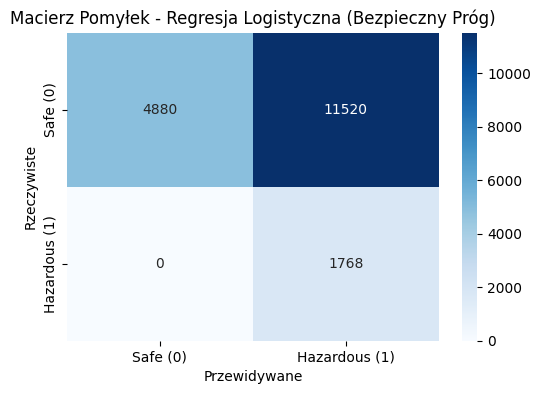


Wynik cost_function dla bezpiecznego progu: -11520


In [ ]:
from pipeline_and_scorer import cost_function
best_lr_model = grid_lr.best_estimator_

y_proba_test = best_lr_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba_test)

safe_idx = np.where(tpr >= 1)[0][0]
safe_threshold = thresholds[safe_idx]

print(f"\nBezpieczny próg decyzyjny (ratujący Ziemię): {safe_threshold:.4f}")

y_pred_test_safe = (y_proba_test >= safe_threshold).astype(int)

print("\nEwaluacja modelu Regresji Logistycznej z przesuniętym progiem:")
print(classification_report(y_test, y_pred_test_safe))

cm = confusion_matrix(y_test, y_pred_test_safe)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Safe (0)', 'Hazardous (1)'], 
            yticklabels=['Safe (0)', 'Hazardous (1)'])
plt.xlabel('Przewidywane')
plt.ylabel('Rzeczywiste')
plt.title('Macierz Pomyłek - Regresja Logistyczna (Bezpieczny Próg)')
plt.show()

koszt_safe = cost_function(y_test, y_pred_test_safe)
print(f"\nWynik cost_function dla bezpiecznego progu: {koszt_safe}")